В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням алгоритмів бустингу: XGBoost та LightGBM, а також використаємо бібліотеку HyperOpt для оптимізації гіперпараметрів.

0. Зчитайте дані `train.csv` в змінну `raw_df` та скористайтесь наведеним кодом нижче аби розділити дані на трнувальні та валідаційні і розділити дані на ознаки з матириці Х та цільову змінну. Назви змінних `train_inputs, train_targets, train_inputs, train_targets` можна змінити на ті, які Вам зручно.

  Наведений скрипт - частина отриманого мною скрипта для обробки даних. Ми тут не викнуємо масштабування та обробку категоріальних змінних, бо хочемо це делегувати алгоритмам, які будемо використовувати. Якщо щось не розумієте в наведених скриптах, рекомендую розібратись: навичка читати код - важлива складова роботи в машинному навчанні.

In [98]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from typing import Tuple, Dict, Any
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, auc, roc_auc_score


def split_train_val(df: pd.DataFrame, target_col: str, test_size: float = 0.2, random_state: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Split the dataframe into training and validation sets.

    Args:
        df (pd.DataFrame): The raw dataframe.
        target_col (str): The target column for stratification.
        test_size (float): The proportion of the dataset to include in the validation split.
        random_state (int): Random state for reproducibility.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: Training and validation dataframes.
    """
    train_df, val_df = train_test_split(df, test_size=test_size, random_state=random_state, stratify=df[target_col])
    return train_df, val_df


def separate_inputs_targets(df: pd.DataFrame, input_cols: list, target_col: str) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Separate inputs and targets from the dataframe.

    Args:
        df (pd.DataFrame): The dataframe.
        input_cols (list): List of input columns.
        target_col (str): Target column.

    Returns:
        Tuple[pd.DataFrame, pd.Series]: DataFrame of inputs and Series of targets.
    """
    inputs = df[input_cols].copy()
    targets = df[target_col].copy()
    return inputs, targets

In [99]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [100]:
raw_df = pd.read_csv('/content/drive/MyDrive/ML_homework/Датасети/Bank Customer Churn Prediction (DLU Course c.3)/train.csv')

In [101]:
raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [102]:
train_df, val_df = split_train_val(raw_df, 'Exited')

In [103]:
train_inputs, train_targets = separate_inputs_targets(train_df, train_df.drop(columns=['id', 'CustomerId', 'Surname', 'Exited']).columns.tolist(), 'Exited')

In [104]:
val_inputs, val_targets = separate_inputs_targets(val_df, val_df.drop(columns=['id', 'CustomerId', 'Surname', 'Exited']).columns.tolist(), 'Exited')

1. В тренувальному та валідаційному наборі перетворіть категоріальні ознаки на тип `category`. Можна це зробити двома способами:
 1. `df[col_name].astype('category')`, як було продемонстровано в лекції
 2. використовуючи метод `pd.Categorical(df[col_name])`

In [105]:
cat_features = train_inputs.select_dtypes(include='object').columns
train_inputs[cat_features] = train_inputs[cat_features].astype('category')
val_inputs[cat_features] = val_inputs[cat_features].astype('category')

2. Навчіть на отриманих даних модель `XGBoostClassifier`. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів XGBoostClassifier - тут https://xgboost.readthedocs.io/en/stable/parameter.html#global-config

  **Важливо:** зробіть такі налаштування `XGBoostClassifier` аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Можна також, якщо працюєте в Google Colab, увімкнути можливість використання GPU (`Runtime -> Change runtime type -> T4 GPU`) і встановити параметр `device='cuda'` в `XGBoostClassifier` для пришвидшення тренування бустинг моделі.
  
  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням DecisionTrees раніше. Чи вийшло покращити якість?

In [106]:
def compute_auroc_and_build_roc(model, inputs, targets, name=''):
  # Predict probabilities
  y_pred_proba = model.predict_proba(inputs)[:, 1]

  # Compute ROC curve
  fpr, tpr, thresholds = roc_curve(targets, y_pred_proba)

    # Compute AUROC
  roc_auc = auc(fpr, tpr)
  print(f'AUROC for {name}: {roc_auc:.4f}')

  # Plot the ROC curve
  plt.figure()
  plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) Curve for {name}')
  plt.legend(loc="lower right")
  plt.show()

In [107]:
xgb_clf = XGBClassifier(
    max_depth=3,
    n_estimators=10,
    enable_categorical=True,  # для категорійних ознак
    #use_label_encoder=False,  # щоб уникнути попереджень, якщо використовуєте нові версії XGBoost
    missing=np.nan,  # явне вказування пропущених значень
    device='cuda'
)

xgb_clf.fit(train_inputs, train_targets)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=10,
              n_jobs=None, num_parallel_tree=None, ...)

AUROC for Training: 0.9330


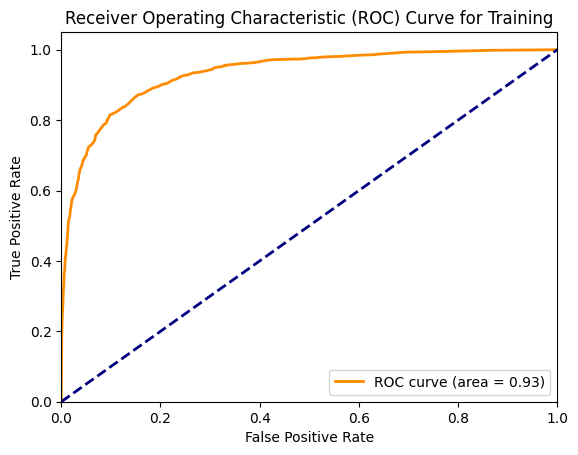

AUROC for Validation: 0.9326


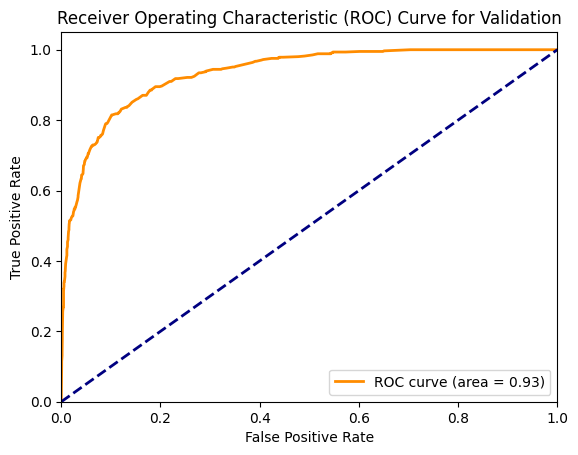

In [108]:
compute_auroc_and_build_roc(xgb_clf, train_inputs, train_targets, 'Training')
compute_auroc_and_build_roc(xgb_clf, val_inputs, val_targets, 'Validation')

Хороша модель, майже відсутня різниця в метриках між тренувальним та валідаційним набором даних, тобто модель добре узагальнює і відсутнє перенавчання. Також результат кращий порівняно з DecisionTrees раніше.

3. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `XGBoostClassifier` з лекції знайдіть оптимальні значення гіперпараметрів `XGBoostClassifier` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **20**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. В ній ми маємо задати loss - це може будь-яка метрика, але бажано використовувтаи ту, яка цільова в вашій задачі. Чим менший лосс - тим ліпша модель на думку hyperopt. Тож, тут нам треба задати loss - негативне значення AUROC. В лекції ми натомість використовували Accuracy.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_clf` модель `XGBoostClassifier` з найкращими гіперпараметрами
    - навчіть модель `final_clf`
    - оцініть якість моделі `final_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (2) цього завдання?

In [109]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

In [110]:
def objective(params):
    clf = XGBClassifier(
    n_estimators=int(params['n_estimators']),
        learning_rate=params['learning_rate'],
        max_depth=int(params['max_depth']),
        min_child_weight=params['min_child_weight'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        gamma=params['gamma'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        enable_categorical=True,
        use_label_encoder=False,
        missing=np.nan,
        device='cuda',
        early_stopping_rounds=10
    )

    clf.fit(
        train_inputs,
        train_targets,
        eval_set=[(val_inputs, val_targets)],
        verbose=False)

    pred_probas = clf.predict_proba(val_inputs)[:, 1]
    auroc = roc_auc_score(val_targets, pred_probas)

    return {'loss': -auroc, 'status': STATUS_OK}

# Простір гіперпараметрів
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 500, 25),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth': hp.quniform('max_depth', 3, 15, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'gamma': hp.uniform('gamma', 0, 0.5),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1)
}

# Оптимізація
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=20, trials=trials)

# Перетворення значень гіперпараметрів у кінцеві типи
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Найкращі гіперпараметри: ", best)

  0%|          | 0/20 [00:00<?, ?trial/s, best loss=?]

/usr/local/lib/python3.11/dist-packages/xgboost/callback.py:386: UserWarning: [15:07:57] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()



  5%|▌         | 1/20 [00:00<00:08,  2.36trial/s, best loss: -0.9305014061321077]

/usr/local/lib/python3.11/dist-packages/xgboost/callback.py:386: UserWarning: [15:07:58] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()



 10%|█         | 2/20 [00:01<00:13,  1.37trial/s, best loss: -0.9358532821181151]

...

 90%|█████████ | 18/20 [00:10<00:00,  2.50trial/s, best loss: -0.9370797036833802]

/usr/local/lib/python3.11/dist-packages/xgboost/callback.py:386: UserWarning: [15:08:08] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()



 95%|█████████▌| 19/20 [00:10<00:00,  3.03trial/s, best loss: -0.9370797036833802]

/usr/local/lib/python3.11/dist-packages/xgboost/callback.py:386: UserWarning: [15:08:08] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.11/dist-packages/xgboost/callback.py:386: UserWarning: [15:08:08] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()



100%|██████████| 20/20 [00:10<00:00,  1.83trial/s, best loss: -0.9370797036833802]
Найкращі гіперпараметри:  {'colsample_bytree': np.float64(0.8690448016863108), 'gamma': np.float64(0.08866603370502824), 'learning_rate': np.float64(0.27792846271549215), 'max_depth': 4, 'min_child_weight': 9, 'n_estimators': 300, 'reg_alpha': np.float64(0.6478614503014593), 'reg_lambda': np.float64(0.7725415335412901), 'subsample': np.float64(0.8124645213860447)}


In [111]:
final_clf = XGBClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    min_child_weight=best['min_child_weight'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    gamma=best['gamma'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    enable_categorical=True,
    use_label_encoder=False,
    missing=np.nan,
    device='cuda',
)

In [112]:
final_clf.fit(train_inputs, train_targets)

/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [15:08:08] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=np.float64(0.8690448016863108), device='cuda',
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=np.float64(0.08866603370502824), grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=np.float64(0.27792846271549215), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=9, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

AUROC for Training: 0.9771


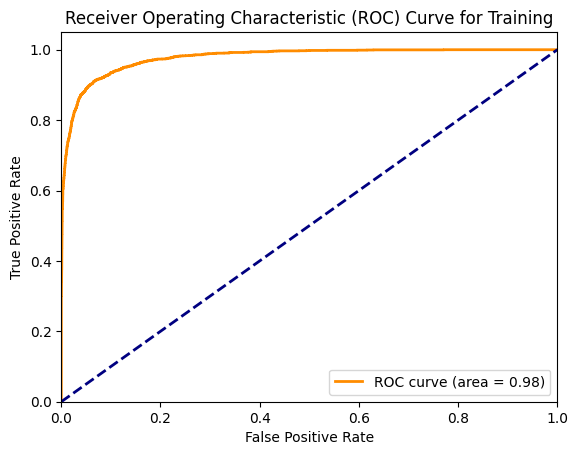

AUROC for Validation: 0.9234


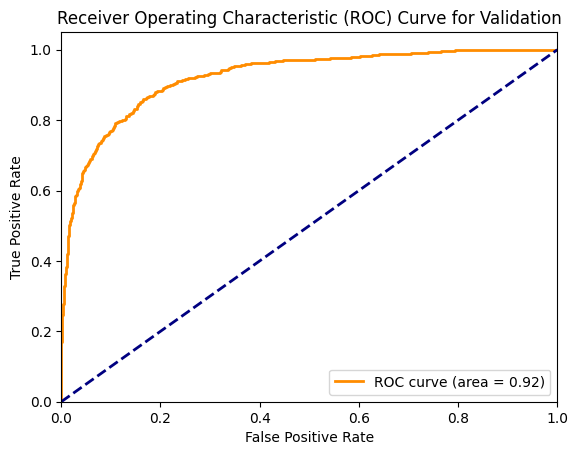

In [113]:
compute_auroc_and_build_roc(final_clf, train_inputs, train_targets, 'Training')
compute_auroc_and_build_roc(final_clf, val_inputs, val_targets, 'Validation')

Метрики покращилися як на тренувальному так і на валідаційному наборі даних і різниця між метриками також не дуже велика, тобто немає перенавчання

4. Навчіть на наших даних модель LightGBM. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів LightGBM - тут https://lightgbm.readthedocs.io/en/latest/Parameters.html

  **Важливо:** зробіть такі налаштування LightGBM аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Аби передати категоріальні колонки в LightGBM - необхідно виявити їх індекси і передати в параметрі `cat_feature=cat_feature_indexes`

  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням XGBoostClassifier раніше. Чи вийшло покращити якість?

In [114]:
import lightgbm as lgb

In [115]:
cat_feature_indexes = [train_inputs.columns.get_loc(col) for col in cat_features]

In [116]:
lgb_clf = lgb.LGBMClassifier(
    max_depth=3,
    n_estimators=50,
    learning_rate=0.1,
    cat_feature=cat_feature_indexes,
    missing=np.nan,
    verbose=-1
)

lgb_clf.fit(train_inputs, train_targets, eval_set=[(val_inputs, val_targets)])

LGBMClassifier(cat_feature=[1, 2], max_depth=3, missing=nan, n_estimators=50,
               verbose=-1)

AUROC for Training: 0.9388


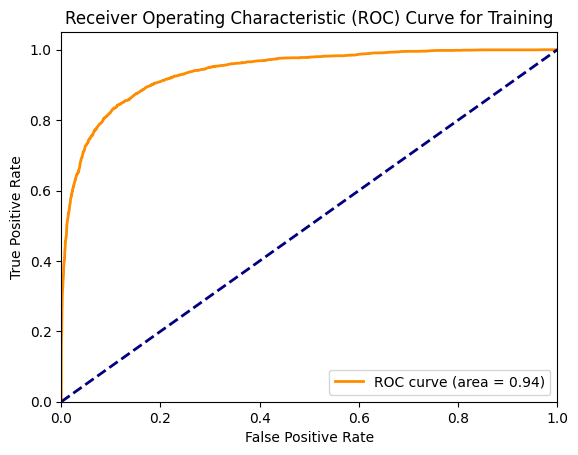

AUROC for Validation: 0.9362


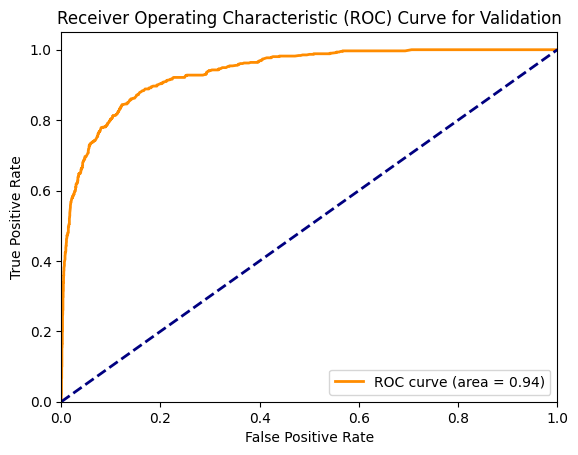

In [117]:
compute_auroc_and_build_roc(lgb_clf, train_inputs, train_targets, 'Training')
compute_auroc_and_build_roc(lgb_clf, val_inputs, val_targets, 'Validation')

Результат схожий до XGBoostClassifier без підбору гіперпараметрів, але трішки вищі метрики. А порівняно з попередньою моделлю ця краще узагальнює

5. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `LightGBM` з лекції знайдіть оптимальні значення гіперпараметрів `LightGBM` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **10**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. І тут ми також ставимо loss - негативне значення AUROC, як і при пошуці гіперпараметрів для XGBoost. До речі, можна спробувати написати код так, аби в objective передавати лише модель і не писати схожий код двічі :)

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_lgb_clf` модель `LightGBM` з найкращими гіперпараметрами
    - навчіть модель `final_lgb_clf`
    - оцініть якість моделі `final_lgb_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (4) цього завдання?

In [118]:
def objective(params):
    clf = lgb.LGBMClassifier(
        n_estimators=int(params['n_estimators']),  # Кількість дерев у ансамблі (кількість ітерацій бустингу)
        learning_rate=params['learning_rate'],  # Коефіцієнт, на який зменшується внесок кожного доданого дерева
        max_depth=int(params['max_depth']),  # Максимальна глибина кожного дерева
        num_leaves=int(params['num_leaves']),  # Максимальна кількість листків, що дозволяємо кожному дереву мати.
        min_child_weight=params['min_child_weight'],  # Мінімальна сума ваг всіх вибірок, необхідна в кінцевому вузлі
        subsample=params['subsample'],  # Частка вибірок, що використовуються для побудови кожного дерева
        colsample_bytree=params['colsample_bytree'],  # Частка ознак, що використовуються при побудові кожного дерева
        reg_alpha=params['reg_alpha'],  # Параметр регуляризації L1 (Lasso)
        reg_lambda=params['reg_lambda'],  # Параметр регуляризації L2 (Ridge)
        min_split_gain=params['min_split_gain'],  # Мінімальне зменшення втрат, необхідне для виконання поділу
        cat_feature=cat_feature_indexes,  # Індекси категорійних ознак
        verbose=-1
    )

    clf.fit(train_inputs, train_targets, eval_set=[(val_inputs, val_targets)])

    pred_probas = clf.predict_proba(val_inputs)[:, 1]
    auroc = roc_auc_score(val_targets, pred_probas)

    return {'loss': -auroc, 'status': STATUS_OK}

# Простір гіперпараметрів
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 500, 25),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth': hp.quniform('max_depth', 3, 15, 1),
    'num_leaves': hp.quniform('num_leaves', 20, 150, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1),
    'min_split_gain': hp.uniform('min_split_gain', 0, 0.1)  # додано мінімальне зменшення втрат для поділу
}

# Оптимізація
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=10, trials=trials)

# Перетворення значень гіперпараметрів у кінцеві типи
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['num_leaves'] = int(best['num_leaves'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Найкращі гіперпараметри: ", best)

100%|██████████| 10/10 [00:07<00:00,  1.35trial/s, best loss: -0.9345510666026476]
Найкращі гіперпараметри:  {'colsample_bytree': np.float64(0.5614927762869424), 'learning_rate': np.float64(0.06256822295003917), 'max_depth': 6, 'min_child_weight': 8, 'min_split_gain': np.float64(0.03890712906323285), 'n_estimators': 175, 'num_leaves': 114, 'reg_alpha': np.float64(0.9835276169280314), 'reg_lambda': np.float64(0.3044691402730533), 'subsample': np.float64(0.5025776235169972)}


In [119]:
final_lgb_clf = lgb.LGBMClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    num_leaves=best['num_leaves'],
    min_child_weight=best['min_child_weight'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    min_split_gain=best['min_split_gain'],
    cat_feature=cat_feature_indexes,
    missing=np.nan
)

In [120]:
final_lgb_clf.fit(train_inputs, train_targets)

LGBMClassifier(cat_feature=[1, 2],
               colsample_bytree=np.float64(0.5614927762869424),
               learning_rate=np.float64(0.06256822295003917), max_depth=6,
               min_child_weight=8,
               min_split_gain=np.float64(0.03890712906323285), missing=nan,
               n_estimators=175, num_leaves=114,
               reg_alpha=np.float64(0.9835276169280314),
               reg_lambda=np.float64(0.3044691402730533),
               subsample=np.float64(0.5025776235169972))

AUROC for Training: 0.9620


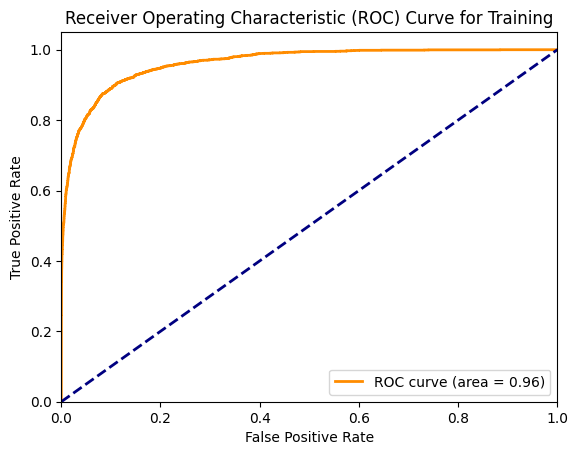

AUROC for Validation: 0.9346


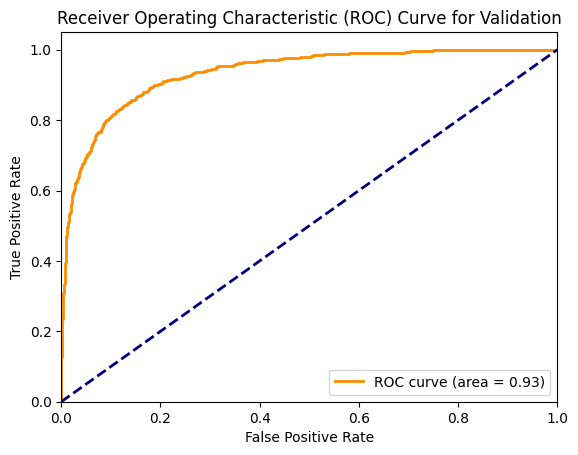

In [121]:
compute_auroc_and_build_roc(final_lgb_clf, train_inputs, train_targets, 'Training')
compute_auroc_and_build_roc(final_lgb_clf, val_inputs, val_targets, 'Validation')

Після підбору гіперпараметрів покращилася якісь класифікації на тренувальному наборі, але на валідаційному трішки навіть гірше стало.

6. Оберіть модель з експериментів в цьому ДЗ і зробіть новий `submission` на Kaggle та додайте код для цього і скріншот скора на публічному лідерборді.
  
  **Напишіть коментар, чому ви обрали саме цю модель?**

  І я вас вітаю - це останнє завдання з цим набором даних 💪 На цьому етапі корисно проаналізувати, які моделі показали себе найкраще і подумати, чому.

In [122]:
!pip install opendatasets --upgrade --quiet

In [123]:
import opendatasets as od

In [124]:
dataset_url = 'https://www.kaggle.com/datasets/shubhammeshram579/bank-customer-churn-prediction'

In [125]:
od.download(dataset_url)

Skipping, found downloaded files in "./bank-customer-churn-prediction" (use force=True to force download)


In [126]:
!kaggle competitions download -c bank-customer-churn-prediction-dlu-course-c-3 -f test.csv

test.csv: Skipping, found more recently modified local copy (use --force to force download)


In [127]:
test_raw_df = pd.read_csv('/content/test.csv')

In [128]:
test_raw_df

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,24995,15642997.0,Chukwumaobim,639.0,Spain,Male,38.0,10.0,0.00,2.0,1.0,1.0,49637.65
9996,24996,15739271.0,Clements,678.0,Spain,Male,39.0,9.0,0.00,2.0,1.0,1.0,142513.50
9997,24997,15756743.0,Chidiebere,774.0,France,Male,30.0,9.0,0.00,2.0,1.0,0.0,4861.72
9998,24998,15680167.0,Yermakova,595.0,France,Male,38.0,6.0,144875.79,1.0,1.0,0.0,126469.09


In [129]:
test_raw_df.drop(columns=['id', 'CustomerId', 'Surname'], inplace=True)

In [130]:
test_raw_df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86
1,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28
2,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45
3,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87
4,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97
...,...,...,...,...,...,...,...,...,...,...
9995,639.0,Spain,Male,38.0,10.0,0.00,2.0,1.0,1.0,49637.65
9996,678.0,Spain,Male,39.0,9.0,0.00,2.0,1.0,1.0,142513.50
9997,774.0,France,Male,30.0,9.0,0.00,2.0,1.0,0.0,4861.72
9998,595.0,France,Male,38.0,6.0,144875.79,1.0,1.0,0.0,126469.09


In [131]:
test_raw_df_cat_features = test_raw_df.select_dtypes(include='object').columns
test_raw_df[test_raw_df_cat_features] = test_raw_df[test_raw_df_cat_features].astype('category')

In [132]:
predict_exited = lgb_clf.predict_proba(test_raw_df)[:,1]

In [133]:
test_raw_df['Exited'] = predict_exited

In [134]:
test_raw_df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86,0.118777
1,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28,0.024281
2,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45,0.074264
3,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87,0.508714
4,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97,0.049218
...,...,...,...,...,...,...,...,...,...,...,...
9995,639.0,Spain,Male,38.0,10.0,0.00,2.0,1.0,1.0,49637.65,0.016853
9996,678.0,Spain,Male,39.0,9.0,0.00,2.0,1.0,1.0,142513.50,0.021410
9997,774.0,France,Male,30.0,9.0,0.00,2.0,1.0,0.0,4861.72,0.010548
9998,595.0,France,Male,38.0,6.0,144875.79,1.0,1.0,0.0,126469.09,0.080627


In [135]:
!kaggle competitions download -c bank-customer-churn-prediction-dlu-course-c-3 -f sample_submission.csv

sample_submission.csv: Skipping, found more recently modified local copy (use --force to force download)


In [136]:
sample_submission = pd.read_csv('/content/sample_submission.csv')

In [137]:
sample_submission['Exited'] = test_raw_df['Exited']

In [138]:
sample_submission

,id,Exited
0,15000,0.118777
1,15001,0.024281
2,15002,0.074264
3,15003,0.508714
4,15004,0.049218
...,...,...
9995,24995,0.016853
9996,24996,0.021410
9997,24997,0.010548
9998,24998,0.080627


In [139]:
output_path = '/content/submission_log_reg_XLGB_V_3.csv'

In [140]:
sample_submission.to_csv(output_path, index=False)

Я обрав варіант моделі LGBMClassifier без підбору гіперпараметрів за допомогою hyperopt, так як вона показала найкращий результат на валідаційному наборі даних